# Node Extractor — Training

Multi-label image classifier: predicts which object categories are present in an image from its SigLIP embedding.

**Pipeline:**
1. Build node vocabulary from merged JSONL
2. Pre-extract SigLIP embeddings (one-time, cached to HDF5)
3. Train a cross-attention transformer with Asymmetric Loss
4. Evaluate on GQA val split

**Prerequisites:**
- Run `python poc_scripts/dataset_generation/merge_vg_gqa.py` to generate `data/merged/train.jsonl` and `val.jsonl`
- SigLIP model at `/home/shaswata/Desktop/models/google`

---
## 1. Setup & Configuration

In [1]:
!pip install -q matplotlib h5py scikit-learn tqdm

In [2]:
import sys
import os
import time
from pathlib import Path
from dataclasses import dataclass

import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Add project root to path
PROJECT_ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "poc_scripts"))

# ── Configuration (tuned for RTX 5090 ~26GB usable VRAM) ────────────────

@dataclass
class Config:
    # Paths
    train_jsonl: str = str(PROJECT_ROOT / "data" / "merged" / "train.jsonl")
    val_jsonl: str = str(PROJECT_ROOT / "data" / "merged" / "val.jsonl")
    train_cache: str = str(PROJECT_ROOT / "data" / "merged" / "train_embeddings.h5")
    val_cache: str = str(PROJECT_ROOT / "data" / "merged" / "val_embeddings.h5")
    vocab_path: str = str(PROJECT_ROOT / "data" / "merged" / "node_vocab.json")
    checkpoint_dir: str = str(PROJECT_ROOT / "data" / "merged" / "checkpoints")
    siglip_model_id: str = "google/siglip-so400m-patch14-384"
    siglip_cache: str = "/home/shaswata/Desktop/models/google"

    # Vocabulary
    min_label_freq: int = 50

    # Model — reduced dimensions to fit 3k+ label queries in ~26GB usable VRAM
    input_dim: int = 1152  # SigLIP pooled embedding dim
    d_model: int = 256
    num_heads: int = 8
    num_layers: int = 2
    ffn_dim: int = 512
    num_image_tokens: int = 16
    dropout: float = 0.1

    # Loss
    gamma_neg: float = 4.0
    gamma_pos: float = 1.0
    clip: float = 0.05
    label_smoothing: float = 0.05

    # Training — doubled batch from 64 (7GB peak → ~14GB, fits in 26GB)
    batch_size: int = 128
    eval_batch_size: int = 256
    lr: float = 1e-3             # doubled with batch size (linear scaling rule)
    weight_decay: float = 0.01
    epochs: int = 500
    warmup_ratio: float = 0.05
    grad_clip: float = 1.0
    patience: int = 10
    num_workers: int = 8
    eval_threshold: float = 0.5
    use_amp: bool = True         # mixed-precision training (fp16)
    compile_model: bool = False
    siglip_extract_batch: int = 64

cfg = Config()

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    gpu_props = torch.cuda.get_device_properties(0)
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM total: {gpu_props.total_memory / 1024**3:.1f} GB")
    free_mem = torch.cuda.mem_get_info()[0] / 1024**3
    print(f"VRAM free:  {free_mem:.1f} GB")
    print(f"CUDA capability: {gpu_props.major}.{gpu_props.minor}")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    print("TF32 enabled, cuDNN benchmark enabled")

os.makedirs(cfg.checkpoint_dir, exist_ok=True)
print(f"\nTraining batch size: {cfg.batch_size}")
print(f"Eval batch size: {cfg.eval_batch_size}")
print(f"Mixed precision: {cfg.use_amp}")
print(f"torch.compile: {cfg.compile_model}")

Device: cuda
GPU: NVIDIA GeForce RTX 5090
VRAM total: 31.3 GB
VRAM free:  26.5 GB
CUDA capability: 12.0
TF32 enabled, cuDNN benchmark enabled

Training batch size: 128
Eval batch size: 256
Mixed precision: True
torch.compile: False


---
## 2. Build Node Vocabulary

Vocabulary loaded from /home/shaswata/Desktop/NeSy_KR/data/merged/node_vocab.json (3453 labels)


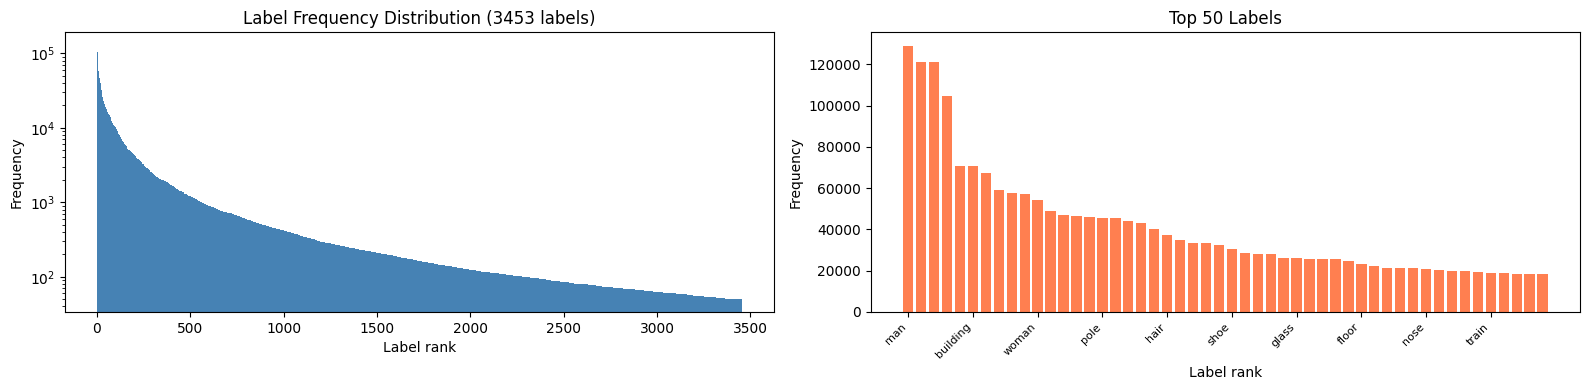


Vocab size: 3453
Top 30: ['man', 'window', 'person', 'tree', 'shirt', 'building', 'wall', 'sign', 'sky', 'ground', 'woman', 'car', 'grass', 'leg', 'leaf', 'pole', 'hand', 'head', 'cloud', 'table', 'hair', 'water', 'light', 'ear', 'eye', 'shoe', 'wheel', 'flower', 'door', 'letter']


In [3]:
from node_extractor.dataset import NodeVocabulary

vocab = NodeVocabulary()

if Path(cfg.vocab_path).exists():
    vocab.load(cfg.vocab_path)
else:
    vocab.build(cfg.train_jsonl, min_freq=cfg.min_label_freq)
    vocab.save(cfg.vocab_path)

# Vocabulary distribution
counts = sorted(vocab.label_counts.values(), reverse=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].bar(range(len(counts)), counts, color="steelblue", width=1.0)
axes[0].set_xlabel("Label rank")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Label Frequency Distribution ({vocab.size} labels)")
axes[0].set_yscale("log")

axes[1].bar(range(min(50, len(counts))), counts[:50], color="coral")
axes[1].set_xlabel("Label rank")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Top 50 Labels")
top_labels = list(vocab.label_counts.keys())[:50]
axes[1].set_xticks(range(0, 50, 5))
axes[1].set_xticklabels(top_labels[::5], rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nVocab size: {vocab.size}")
print(f"Top 30: {list(vocab.label_counts.keys())[:30]}")

---
## 3. Pre-extract SigLIP Embeddings (one-time)

This step runs SigLIP's vision tower over all images and saves embeddings to HDF5. Skip if cache files already exist.

In [4]:
from node_extractor.dataset import build_embedding_cache

def needs_extraction(cache_path: str) -> bool:
    """Check if the cache is missing or has unextracted entries."""
    if not Path(cache_path).exists():
        return True
    import h5py
    with h5py.File(cache_path, "r") as hf:
        if "extracted" not in hf:
            return False  # legacy cache without tracking — assume complete
        return not bool(np.array(hf["extracted"]).all())

need_train = needs_extraction(cfg.train_cache)
need_val = needs_extraction(cfg.val_cache)

if need_train or need_val:
    from transformers import AutoModel, AutoProcessor
    import gc

    print("Loading SigLIP for embedding extraction...")
    siglip_model = AutoModel.from_pretrained(
        cfg.siglip_model_id,
        cache_dir=cfg.siglip_cache,
        torch_dtype=torch.float16,
    ).to(device).eval()

    siglip_processor = AutoProcessor.from_pretrained(
        cfg.siglip_model_id,
        cache_dir=cfg.siglip_cache,
    )
    print(f"SigLIP loaded. Embedding dim: {siglip_model.config.vision_config.hidden_size}")

    if need_train:
        print("\n═══ Extracting train embeddings ═══")
        build_embedding_cache(
            cfg.train_jsonl, cfg.train_cache,
            siglip_model, siglip_processor, device,
            batch_size=cfg.siglip_extract_batch,
        )

    if need_val:
        print("\n═══ Extracting val embeddings ═══")
        build_embedding_cache(
            cfg.val_jsonl, cfg.val_cache,
            siglip_model, siglip_processor, device,
            batch_size=cfg.siglip_extract_batch,
        )

    # Free SigLIP from GPU
    del siglip_model, siglip_processor
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()
    print("\nSigLIP unloaded.")
else:
    print(f"Embedding caches already complete:")
    print(f"  Train: {cfg.train_cache}")
    print(f"  Val:   {cfg.val_cache}")

Embedding caches already complete:
  Train: /home/shaswata/Desktop/NeSy_KR/data/merged/train_embeddings.h5
  Val:   /home/shaswata/Desktop/NeSy_KR/data/merged/val_embeddings.h5


---
## 4. Create Datasets & DataLoaders

In [5]:
from node_extractor.dataset import NodeDataset, RepeatFactorSampler
from torch.utils.data import DataLoader

train_ds = NodeDataset(cfg.train_jsonl, vocab, cfg.train_cache)
val_ds = NodeDataset(cfg.val_jsonl, vocab, cfg.val_cache)

# Repeat Factor Sampler — oversamples images with rare labels
rfs = RepeatFactorSampler(train_ds, vocab)

train_loader = DataLoader(
    train_ds, batch_size=cfg.batch_size,
    sampler=rfs,  # replaces shuffle=True
    num_workers=cfg.num_workers, pin_memory=True,
    drop_last=True, persistent_workers=True,
)
val_loader = DataLoader(
    val_ds, batch_size=cfg.eval_batch_size, shuffle=False,
    num_workers=cfg.num_workers, pin_memory=True,
    persistent_workers=True,
)

# Verify a batch
emb, target = next(iter(train_loader))
print(f"\nTrain batch shape: {emb.shape}  (batch_size={cfg.batch_size})")
print(f"Target shape:      {target.shape}  (vocab_size={vocab.size})")
print(f"Avg positives per sample: {target.sum(dim=1).mean():.1f}")
print(f"Steps per epoch (with RFS): {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Loading targets from /home/shaswata/Desktop/NeSy_KR/data/merged/train.jsonl...
  Samples: 183,019
  Vocab size: 3453
  Avg labels per sample: 15.3
  Classes with >0 samples: 3453
Loading targets from /home/shaswata/Desktop/NeSy_KR/data/merged/val.jsonl...
  Samples: 10,696
  Vocab size: 3453
  Avg labels per sample: 11.7
  Classes with >0 samples: 1283
  RepeatFactorSampler:
    threshold (t)      : 0.000678
    images oversampled : 67,273 / 183,019 (36.8%)
    max repeat factor  : 7.87
    effective epoch size: ~252,041 (was 183,019, 1.38x)

Train batch shape: torch.Size([128, 1152])  (batch_size=128)
Target shape:      torch.Size([128, 3453])  (vocab_size=3453)
Avg positives per sample: 15.6
Steps per epoch (with RFS): 1969
Val batches: 42


---
## 5. Initialize Model

In [6]:
from node_extractor.model import NodeExtractorTransformer

model = NodeExtractorTransformer(
    input_dim=cfg.input_dim,
    vocab_size=vocab.size,
    d_model=cfg.d_model,
    num_heads=cfg.num_heads,
    num_layers=cfg.num_layers,
    ffn_dim=cfg.ffn_dim,
    num_image_tokens=cfg.num_image_tokens,
    dropout=cfg.dropout,
).to(device)

# Parameter breakdown
param_counts = model.count_parameters()
print("Parameter counts:")
for name, count in param_counts.items():
    print(f"  {name:25s}: {count:>10,d}")
print(f"\nTotal trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# torch.compile for kernel fusion (RTX 5090 benefits greatly)
if cfg.compile_model and device == "cuda":
    try:
        model = torch.compile(model, mode="reduce-overhead")
        print("Model compiled with torch.compile (reduce-overhead mode)")
    except Exception as e:
        print(f"torch.compile failed (non-fatal): {e}")

# Estimate GPU memory per batch
param_mem = sum(p.numel() * p.element_size() for p in model.parameters()) / 1024**2
batch_mem_est = (cfg.batch_size * cfg.input_dim * 4 + cfg.batch_size * vocab.size * 4) / 1024**2
print(f"\nModel memory: ~{param_mem:.0f} MB")
print(f"Batch memory estimate: ~{batch_mem_est:.0f} MB (input + output tensors only)")

Parameter counts:
  input_proj               :  4,722,688
  image_pos                :      4,096
  label_queries            :    883,968
  cross_attn_layers        :  1,054,208
  classifier               :        257
  total                    :  6,665,217

Total trainable: 6,665,729

Model memory: ~25 MB
Batch memory estimate: ~2 MB (input + output tensors only)


---
## 6. Training Loop with Live Visualization

In [7]:
from node_extractor.utils import AsymmetricLoss, compute_metrics, CosineWarmupScheduler, EarlyStopping

# Loss, optimizer, scheduler
criterion = AsymmetricLoss(
    gamma_neg=cfg.gamma_neg, gamma_pos=cfg.gamma_pos,
    clip=cfg.clip, label_smoothing=cfg.label_smoothing,
)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay,
)

# Use actual steps per epoch from RFS-aware train_loader
total_steps = len(train_loader) * cfg.epochs
warmup_steps = int(total_steps * cfg.warmup_ratio)
scheduler = CosineWarmupScheduler(optimizer, warmup_steps, total_steps)

early_stopping = EarlyStopping(patience=cfg.patience, mode="max")

print(f"Total steps: {total_steps:,}  (RFS-adjusted)")
print(f"Warmup steps: {warmup_steps:,}")
print(f"Steps per epoch: {len(train_loader):,}")

Total steps: 984,500  (RFS-adjusted)
Warmup steps: 49,225
Steps per epoch: 1,969


In [8]:
# ── Training + Validation functions (AMP-enabled) ────────────────────────

scaler = torch.amp.GradScaler("cuda", enabled=cfg.use_amp)


def train_one_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    n_batches = 0

    for emb, target in loader:
        emb = emb.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        # Mixed-precision forward pass
        with torch.amp.autocast("cuda", enabled=cfg.use_amp):
            logits = model(emb)
            loss = criterion(logits, target)

        # Scaled backward pass
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0
    n_batches = 0
    all_logits = []
    all_targets = []

    for emb, target in loader:
        emb = emb.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=cfg.use_amp):
            logits = model(emb)
            loss = criterion(logits, target)

        total_loss += loss.item()
        n_batches += 1
        all_logits.append(logits.float().cpu())
        all_targets.append(target.cpu())

    all_logits = torch.cat(all_logits, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    metrics = compute_metrics(all_logits, all_targets, threshold)
    metrics["loss"] = total_loss / n_batches
    return metrics


print("Training functions ready (AMP + GradScaler enabled)")
print(f"  Mixed precision: {cfg.use_amp}")
print(f"  Grad clipping: {cfg.grad_clip}")

Training functions ready (AMP + GradScaler enabled)
  Mixed precision: True
  Grad clipping: 1.0


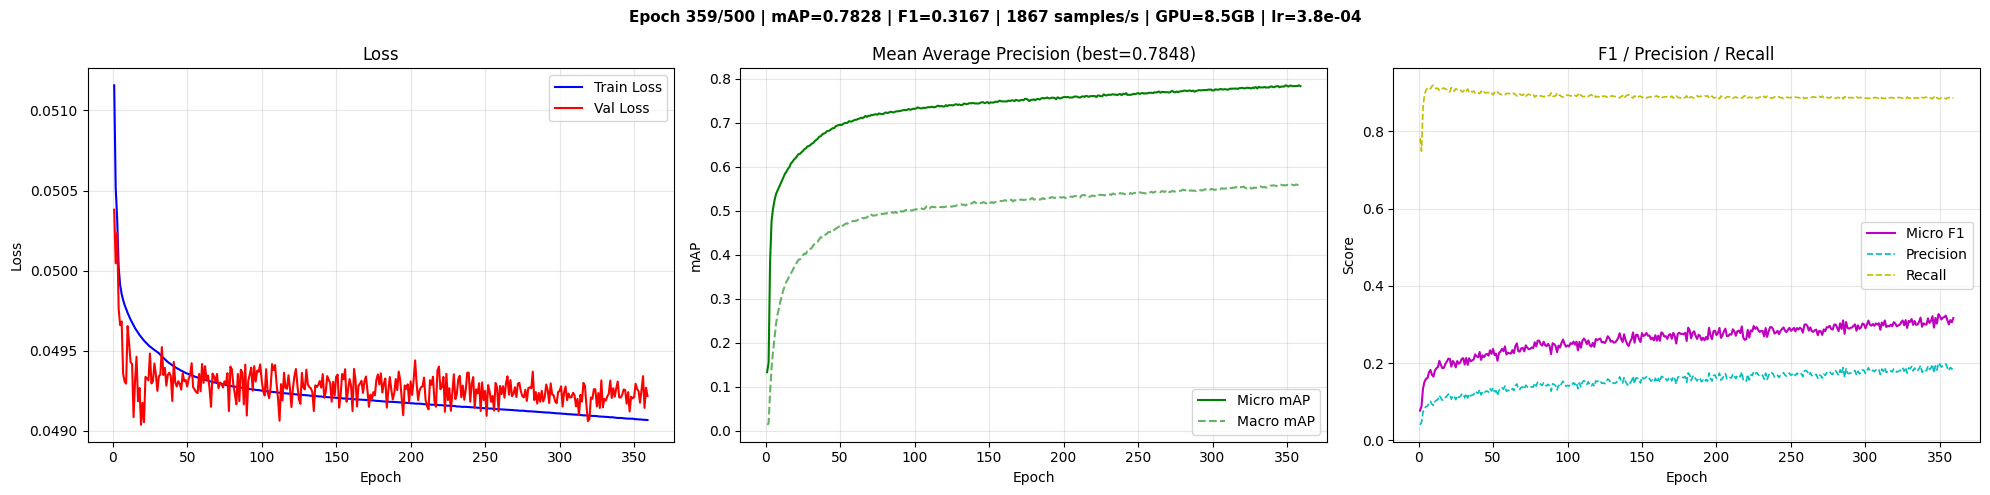


Early stopping at epoch 359. Best mAP=0.7848 at epoch 349

  Training complete
  Best mAP: 0.7848
  Avg epoch time: 125.6s
  Avg throughput: 2007 samples/s
  Peak GPU memory: 8.5 GB
  Checkpoint: /home/shaswata/Desktop/NeSy_KR/data/merged/checkpoints/best_model.pt


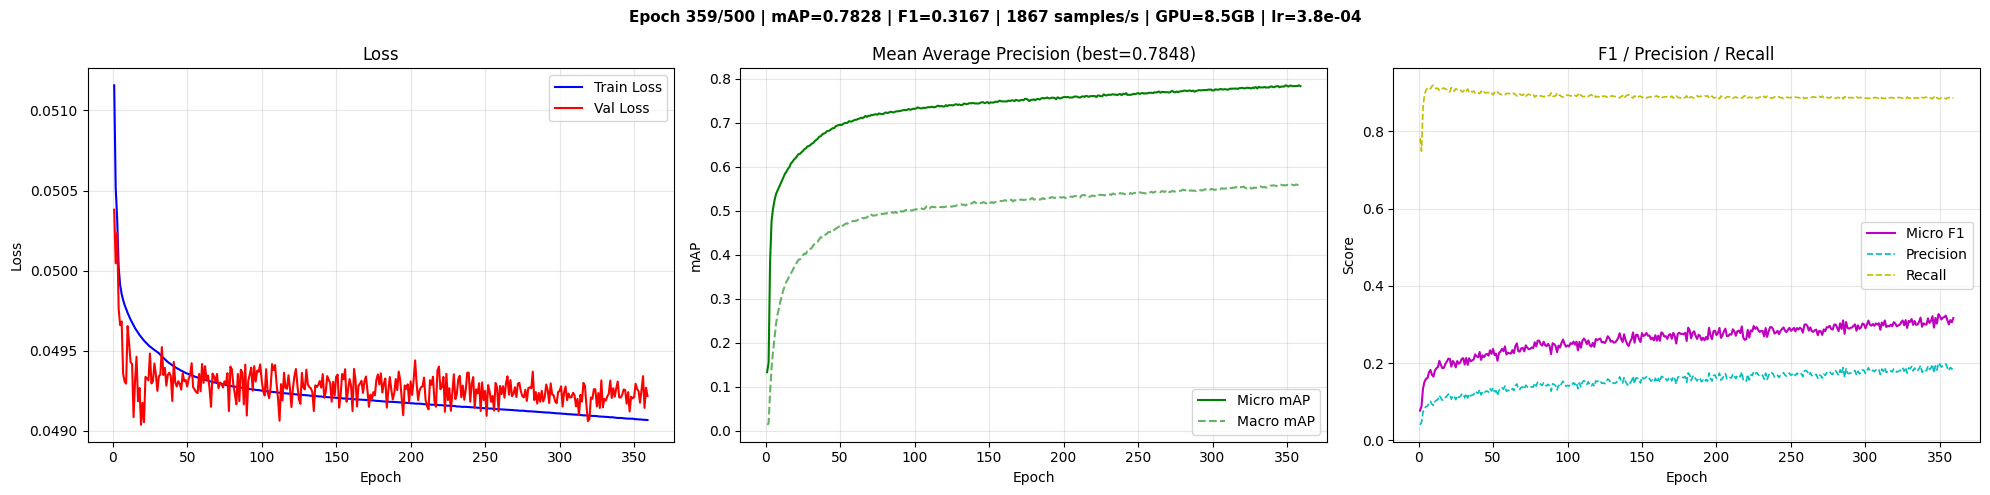

In [9]:
# ── Main training loop with live chart ────────────────────────────────────

history = {
    "train_loss": [], "val_loss": [],
    "mAP": [], "macro_mAP": [],
    "micro_f1": [], "macro_f1": [],
    "micro_precision": [], "micro_recall": [],
    "lr": [], "gpu_mem_gb": [], "epoch_time": [],
}

best_map = 0.0
best_path = os.path.join(cfg.checkpoint_dir, "best_model.pt")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plt.ion()

for epoch in range(1, cfg.epochs + 1):
    t0 = time.time()

    # Advance RFS epoch so fractional draws change each epoch
    rfs.set_epoch(epoch)

    # Train
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, scheduler, device)

    # Validate
    val_metrics = evaluate(model, val_loader, criterion, device, cfg.eval_threshold)

    elapsed = time.time() - t0

    # GPU memory tracking
    gpu_mem = torch.cuda.max_memory_allocated() / 1024**3 if device == "cuda" else 0
    torch.cuda.reset_peak_memory_stats() if device == "cuda" else None

    # Record
    current_lr = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["mAP"].append(val_metrics["mAP"])
    history["macro_mAP"].append(val_metrics["macro_mAP"])
    history["micro_f1"].append(val_metrics["micro_f1"])
    history["macro_f1"].append(val_metrics["macro_f1"])
    history["micro_precision"].append(val_metrics["micro_precision"])
    history["micro_recall"].append(val_metrics["micro_recall"])
    history["lr"].append(current_lr)
    history["gpu_mem_gb"].append(gpu_mem)
    history["epoch_time"].append(elapsed)

    # Throughput (use effective epoch size from RFS)
    samples_per_sec = len(rfs) / elapsed

    # Save best
    if val_metrics["mAP"] > best_map:
        best_map = val_metrics["mAP"]
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "mAP": best_map,
            "config": cfg,
        }, best_path)

    # ── Live chart update ─────────────────────────────────────────────
    clear_output(wait=True)

    for ax in axes:
        ax.clear()

    epochs_x = range(1, epoch + 1)

    # Panel 1: Loss
    axes[0].plot(epochs_x, history["train_loss"], "b-", label="Train Loss", linewidth=1.5)
    axes[0].plot(epochs_x, history["val_loss"], "r-", label="Val Loss", linewidth=1.5)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Panel 2: mAP
    axes[1].plot(epochs_x, history["mAP"], "g-", label="Micro mAP", linewidth=1.5)
    axes[1].plot(epochs_x, history["macro_mAP"], "g--", label="Macro mAP", linewidth=1.5, alpha=0.6)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("mAP")
    axes[1].set_title(f"Mean Average Precision (best={best_map:.4f})")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Panel 3: F1 / Precision / Recall
    axes[2].plot(epochs_x, history["micro_f1"], "m-", label="Micro F1", linewidth=1.5)
    axes[2].plot(epochs_x, history["micro_precision"], "c--", label="Precision", linewidth=1.2)
    axes[2].plot(epochs_x, history["micro_recall"], "y--", label="Recall", linewidth=1.2)
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Score")
    axes[2].set_title("F1 / Precision / Recall")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    is_best = " ★" if val_metrics["mAP"] >= best_map else ""
    fig.suptitle(
        f"Epoch {epoch}/{cfg.epochs} | "
        f"mAP={val_metrics['mAP']:.4f}{is_best} | "
        f"F1={val_metrics['micro_f1']:.4f} | "
        f"{samples_per_sec:.0f} samples/s | "
        f"GPU={gpu_mem:.1f}GB | "
        f"lr={current_lr:.1e}",
        fontsize=11, fontweight="bold",
    )
    plt.tight_layout()
    display(fig)

    # Early stopping
    if early_stopping(val_metrics["mAP"], epoch):
        print(f"\nEarly stopping at epoch {epoch}. Best mAP={best_map:.4f} at epoch {early_stopping.best_epoch}")
        break

plt.ioff()

# Final summary
avg_time = np.mean(history["epoch_time"])
avg_throughput = len(rfs) / avg_time
print(f"\n{'='*60}")
print(f"  Training complete")
print(f"{'='*60}")
print(f"  Best mAP: {best_map:.4f}")
print(f"  Avg epoch time: {avg_time:.1f}s")
print(f"  Avg throughput: {avg_throughput:.0f} samples/s")
print(f"  Peak GPU memory: {max(history['gpu_mem_gb']):.1f} GB")
print(f"  Checkpoint: {best_path}")

---
## 7. Evaluation — Per-class Analysis

Loaded best checkpoint from epoch 349 (mAP=0.7848)

  TOP 20 CLASSES (by AP)
  Rank                 Label        AP   Support
     1               almonds    1.0000         2
     2         cash register    1.0000         1
     3            onion ring    1.0000         1
     4              scooters    1.0000         2
     5                router    1.0000         2
     6         mountain side    1.0000         1
     7                  tofu    1.0000         2
     8                raisin    1.0000         1
     9             classroom    1.0000         2
    10            snowboards    1.0000         4
    11                diaper    1.0000         2
    12                 rhino    1.0000         2
    13                 buoys    1.0000         1
    14              macaroni    1.0000         5
    15             projector    1.0000         4
    16              tortilla    1.0000         3
    17                  lego    1.0000         1
    18          sweet potato    1.0000   

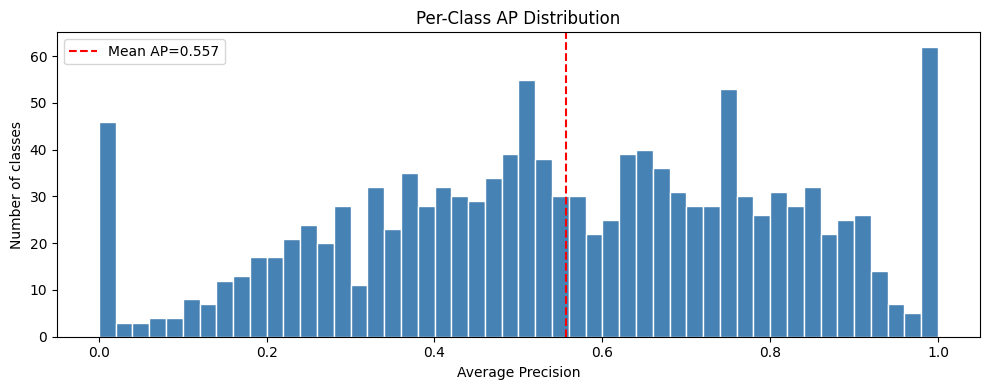

In [10]:
# Load best checkpoint and run full evaluation
from sklearn.metrics import average_precision_score

best_path = os.path.join(cfg.checkpoint_dir, "best_model.pt")
checkpoint = torch.load(best_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']} (mAP={checkpoint['mAP']:.4f})")

# Collect all val predictions
model.eval()
all_logits = []
all_targets = []

with torch.no_grad():
    for emb, target in val_loader:
        logits = model(emb.to(device))
        all_logits.append(logits.cpu())
        all_targets.append(target.cpu())

all_logits = torch.cat(all_logits, dim=0)
all_targets = torch.cat(all_targets, dim=0)
all_probs = torch.sigmoid(all_logits).numpy()
all_targets_np = all_targets.numpy()

# Per-class AP
has_pos = all_targets_np.sum(axis=0) > 0
per_class_ap = np.zeros(vocab.size)
for i in range(vocab.size):
    if has_pos[i]:
        per_class_ap[i] = average_precision_score(all_targets_np[:, i], all_probs[:, i])

# Sort by AP
sorted_indices = np.argsort(per_class_ap)[::-1]

print(f"\n{'='*70}")
print(f"  TOP 20 CLASSES (by AP)")
print(f"{'='*70}")
print(f"  {'Rank':>4s}  {'Label':>20s}  {'AP':>8s}  {'Support':>8s}")
for rank, idx in enumerate(sorted_indices[:20]):
    label = vocab.idx_to_label[idx]
    ap = per_class_ap[idx]
    support = int(all_targets_np[:, idx].sum())
    print(f"  {rank+1:4d}  {label:>20s}  {ap:8.4f}  {support:8d}")

print(f"\n{'='*70}")
print(f"  BOTTOM 20 CLASSES (by AP, with >0 support)")
print(f"{'='*70}")
bottom = [i for i in sorted_indices[::-1] if has_pos[i]][:20]
for rank, idx in enumerate(bottom):
    label = vocab.idx_to_label[idx]
    ap = per_class_ap[idx]
    support = int(all_targets_np[:, idx].sum())
    print(f"  {rank+1:4d}  {label:>20s}  {ap:8.4f}  {support:8d}")

# AP distribution
fig, ax = plt.subplots(figsize=(10, 4))
valid_aps = per_class_ap[has_pos]
ax.hist(valid_aps, bins=50, color="steelblue", edgecolor="white")
ax.axvline(valid_aps.mean(), color="red", linestyle="--", label=f"Mean AP={valid_aps.mean():.3f}")
ax.set_xlabel("Average Precision")
ax.set_ylabel("Number of classes")
ax.set_title("Per-Class AP Distribution")
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Inference Demo

Load a single image, extract its SigLIP embedding, and show predicted node labels with confidence scores.

/tmp/ipykernel_3139824/2237988657.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


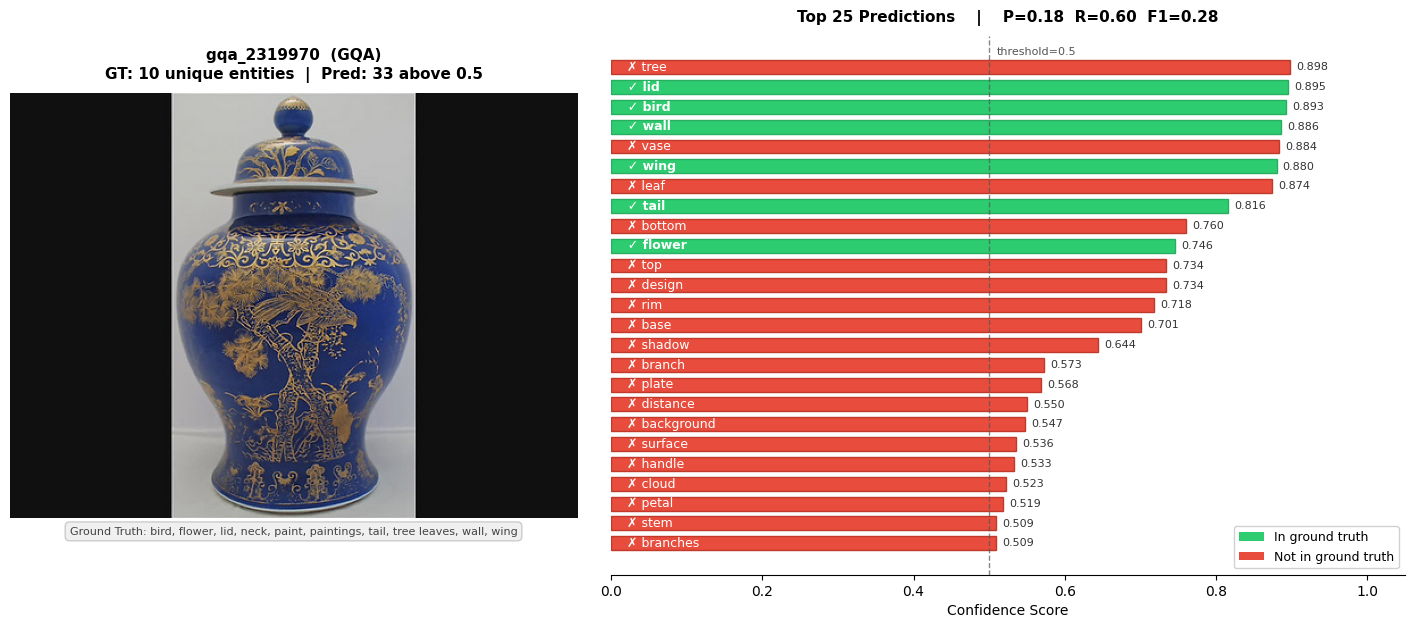

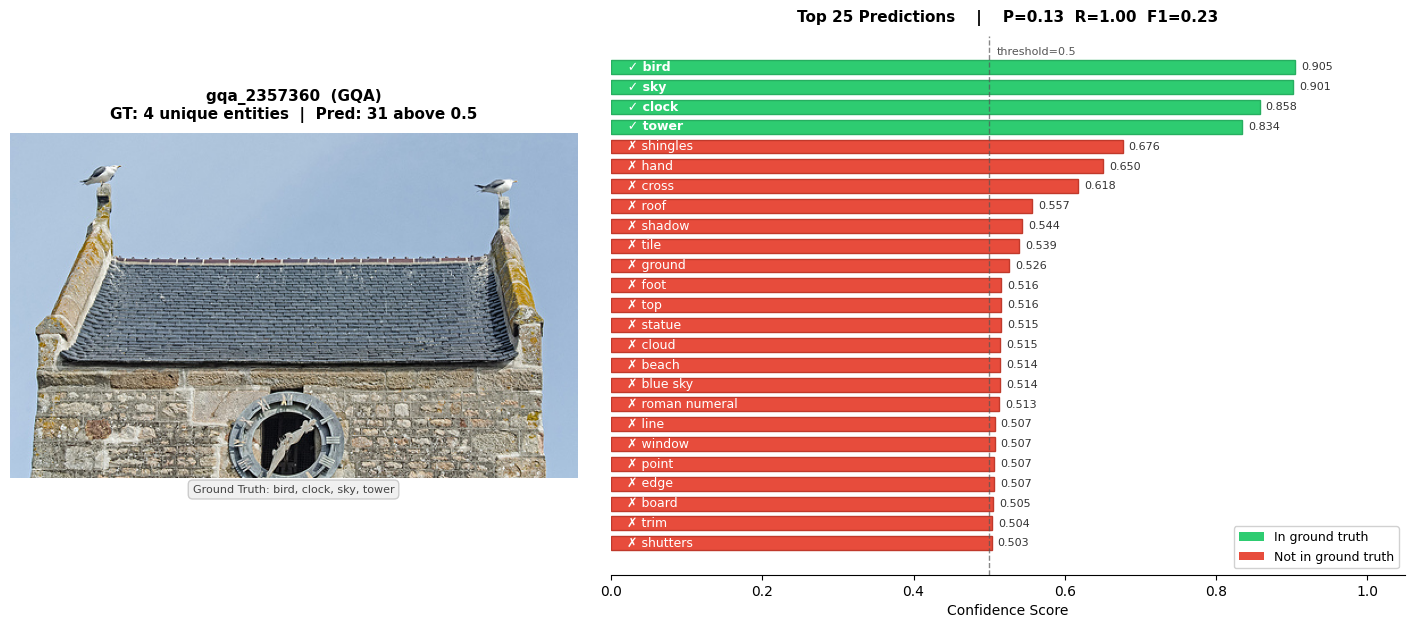

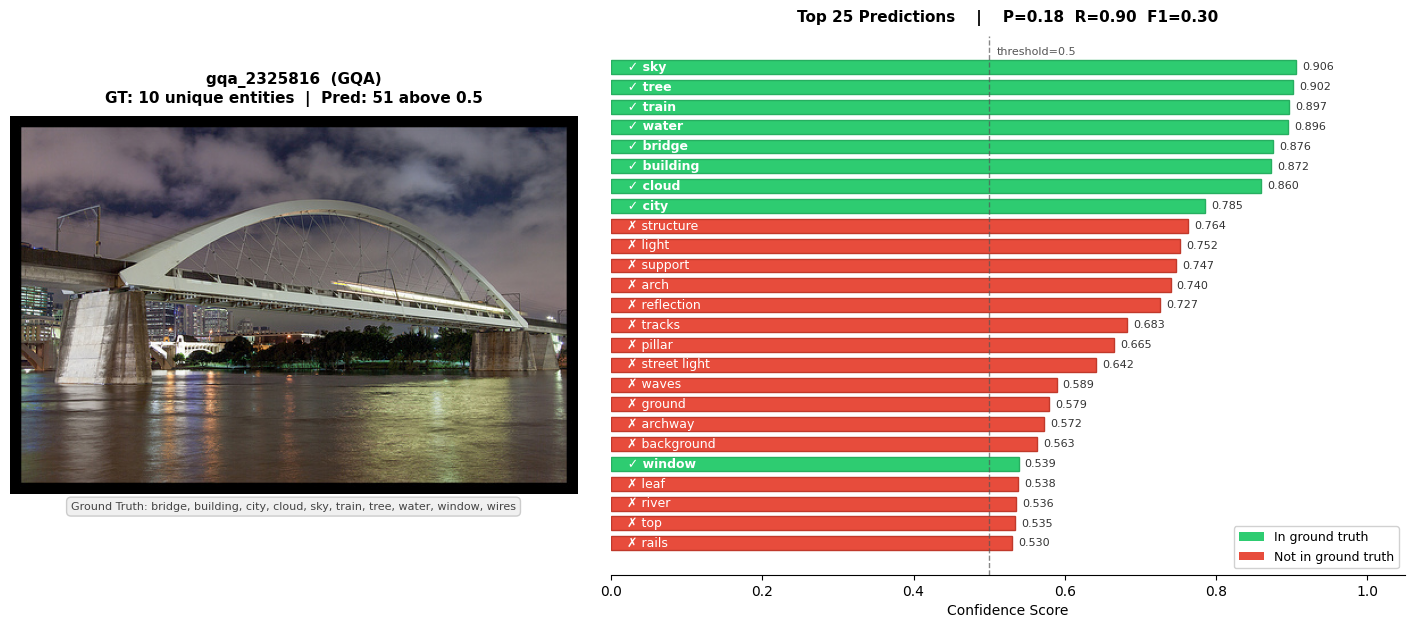

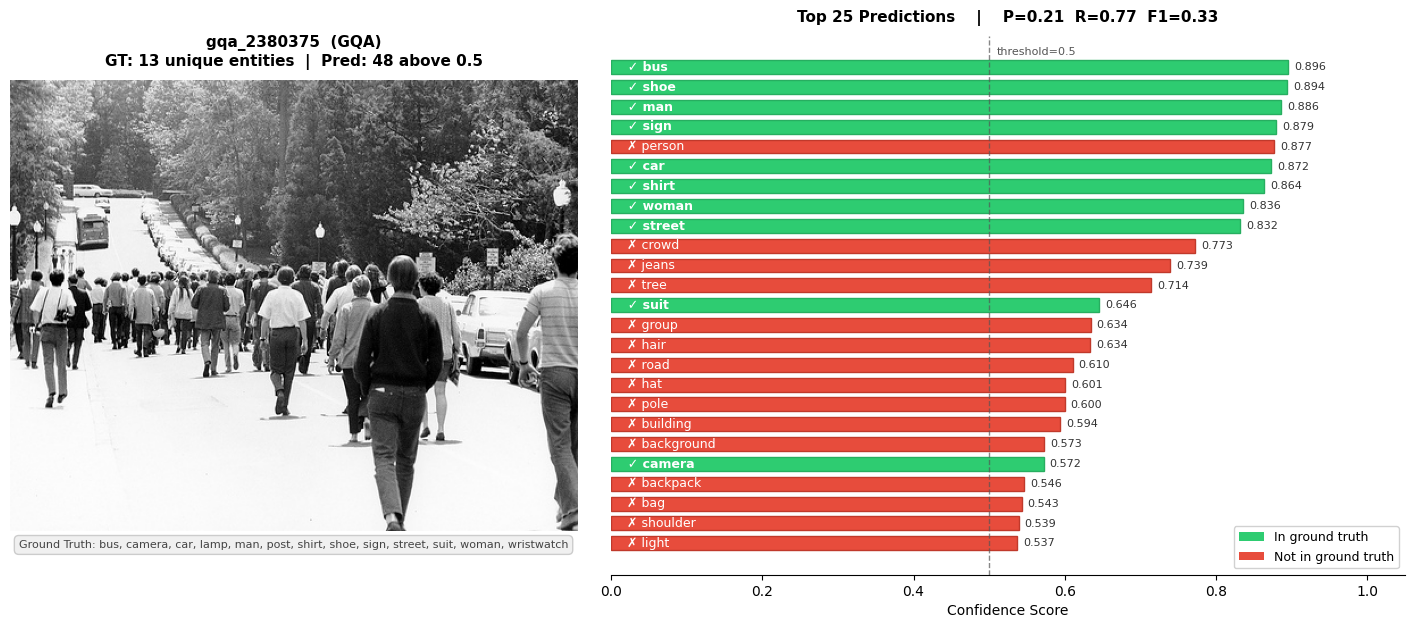

In [13]:
import json
import random
from PIL import Image
from node_extractor.utils import normalize_label

# ── Load val entries and pick random samples ──────────────────────────────

with open(cfg.val_jsonl) as f:
    val_lines = f.readlines()

NUM_VIS = 4
random.seed(123)
vis_indices = random.sample(range(len(val_lines)), NUM_VIS)

model.eval()

for sample_idx in vis_indices:
    entry = json.loads(val_lines[sample_idx])
    gt_labels_raw = [node["label"] for node in entry["groundTruth"]["nodes"]]
    gt_labels_norm = set(normalize_label(l) for l in gt_labels_raw)

    # Predict
    sample_emb, _ = val_ds[sample_idx]
    with torch.no_grad():
        logits = model(sample_emb.unsqueeze(0).to(device))
        probs = torch.sigmoid(logits).squeeze(0).cpu()

    # Top-K predictions
    top_k = 25
    top_scores, top_indices = torch.topk(probs, top_k)
    pred_labels = [vocab.idx_to_label[i.item()] for i in top_indices]
    pred_scores = top_scores.tolist()
    pred_hits = [label in gt_labels_norm for label in pred_labels]

    # Stats
    all_preds = vocab.decode(probs, threshold=cfg.eval_threshold)
    pred_set = set(l for l, _ in all_preds)
    tp = len(pred_set & gt_labels_norm)
    precision = tp / len(pred_set) if pred_set else 0
    recall = tp / len(gt_labels_norm) if gt_labels_norm else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    # ── Build figure: image left, bar chart right ─────────────────────
    fig = plt.figure(figsize=(18, 7))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.4], wspace=0.05)

    # Left panel: image + ground truth
    ax_img = fig.add_subplot(gs[0])
    if entry.get("image_path") and Path(entry["image_path"]).exists():
        img = Image.open(entry["image_path"])
        ax_img.imshow(img)
    else:
        ax_img.text(0.5, 0.5, "Image not available", ha="center", va="center",
                     fontsize=14, transform=ax_img.transAxes)
    ax_img.set_title(
        f"{entry['id']}  ({entry['metadata']['source'].upper()})\n"
        f"GT: {len(gt_labels_norm)} unique entities  |  "
        f"Pred: {len(all_preds)} above {cfg.eval_threshold}",
        fontsize=11, fontweight="bold", pad=10,
    )
    ax_img.axis("off")

    # Ground truth text below image
    gt_display = sorted(gt_labels_norm)
    gt_text = ", ".join(gt_display[:20])
    if len(gt_display) > 20:
        gt_text += f"  (+{len(gt_display)-20} more)"
    ax_img.text(
        0.5, -0.02, f"Ground Truth: {gt_text}",
        ha="center", va="top", fontsize=8, color="#444",
        transform=ax_img.transAxes, wrap=True,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f0f0", edgecolor="#ccc"),
    )

    # Right panel: horizontal bar chart of top-K predictions
    ax_bar = fig.add_subplot(gs[1])
    y_pos = np.arange(top_k)[::-1]
    colors = ["#2ecc71" if hit else "#e74c3c" for hit in pred_hits]
    edge_colors = ["#27ae60" if hit else "#c0392b" for hit in pred_hits]

    bars = ax_bar.barh(y_pos, pred_scores, color=colors, edgecolor=edge_colors, height=0.7)

    # Threshold line
    ax_bar.axvline(cfg.eval_threshold, color="#555", linestyle="--", linewidth=1, alpha=0.7)
    ax_bar.text(cfg.eval_threshold + 0.01, top_k - 0.5, f"threshold={cfg.eval_threshold}",
                fontsize=8, color="#555", va="bottom")

    # Labels on bars
    for i, (label, score, hit) in enumerate(zip(pred_labels, pred_scores, pred_hits)):
        marker = "\u2713" if hit else "\u2717"
        ax_bar.text(
            0.01, y_pos[i], f"  {marker} {label}",
            va="center", ha="left", fontsize=9,
            fontweight="bold" if hit else "normal",
            color="white" if score > 0.3 else "#333",
        )
        ax_bar.text(
            score + 0.008, y_pos[i], f"{score:.3f}",
            va="center", ha="left", fontsize=8, color="#333",
        )

    ax_bar.set_xlim(0, 1.05)
    ax_bar.set_yticks([])
    ax_bar.set_xlabel("Confidence Score", fontsize=10)
    ax_bar.set_title(
        f"Top {top_k} Predictions    |    "
        f"P={precision:.2f}  R={recall:.2f}  F1={f1:.2f}",
        fontsize=11, fontweight="bold", pad=10,
    )
    ax_bar.spines["top"].set_visible(False)
    ax_bar.spines["right"].set_visible(False)
    ax_bar.spines["left"].set_visible(False)

    # Legend
    from matplotlib.patches import Patch
    ax_bar.legend(
        handles=[Patch(facecolor="#2ecc71", label="In ground truth"),
                 Patch(facecolor="#e74c3c", label="Not in ground truth")],
        loc="lower right", fontsize=9, framealpha=0.9,
    )

    plt.tight_layout()
    plt.show()
    print()